## Análise de Churn de clientes

O objetivo será criar um modelo de classificação a fim de prever se eu cliente dará churn ou não.

### Carregamento dos pacotes

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE # técnica usada para oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from funcoes_auxiliares import gerar_avaliar_modelos, undersampling
from sklearn.ensemble import RandomForestClassifier


### Carregamento dos dados e pré-processamento

In [2]:
df_dados = pd.read_csv('customer_churn_dataset.csv', sep = ',')

In [3]:
df_dados.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [4]:
df_dados.shape

(20000, 11)

In [5]:
# verificar dados faltantes e tipos de dados 
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


a coluna Costumer_id não é relevante para a análise de churn, pois representa apenas um identificar do cliente. Podemos podemos retirá-la

In [6]:
df_dados.drop(columns= ['customer_id'], inplace= True)

In [7]:
df_dados.columns

Index(['tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls', 'churn'],
      dtype='object')

In [8]:
df_dados['internet_service'].value_counts()

internet_service
Fiber    10064
DSL       7923
Name: count, dtype: int64

Como consta na própria descrição dos dados, os valores faltantes da coluna internet_service corresponde a outros tipos de serviço. Vamos então preencher.

In [9]:
df_dados.loc[df_dados['internet_service'].isna(), "internet_service"] = 'Outros'

In [10]:
df_dados['internet_service'].value_counts() / df_dados.shape[0]

internet_service
Fiber     0.50320
DSL       0.39615
Outros    0.10065
Name: count, dtype: float64

### Análise exploratória dos dados

In [11]:
# variáveis numéricas
df_dados.describe()

,tenure,monthly_charges,total_charges,support_calls
count,20000.000000,20000.000000,20000.000000,20000.00000
mean,36.467450,70.010531,2543.979209,1.51255
std,20.773984,28.890239,1882.949804,1.23524
min,1.000000,20.000000,20.230000,0.00000
25%,18.000000,45.210000,1045.837500,1.00000
50%,36.000000,70.090000,2096.495000,1.00000
75%,54.000000,95.072500,3690.337500,2.00000
max,72.000000,120.000000,8629.920000,8.00000


In [12]:
# variáveis categóricas
df_dados.describe(include= [object])

,contract,payment_method,internet_service,tech_support,online_security,churn
count,20000,20000,20000,20000,20000,20000
unique,3,4,3,2,2,2
top,Month-to-month,Credit,Fiber,No,No,No
freq,11942,5026,10064,13031,12008,13157


tenure                Axes(0.125,0.53;0.352273x0.35)
monthly_charges    Axes(0.547727,0.53;0.352273x0.35)
total_charges         Axes(0.125,0.11;0.352273x0.35)
support_calls      Axes(0.547727,0.11;0.352273x0.35)
dtype: object

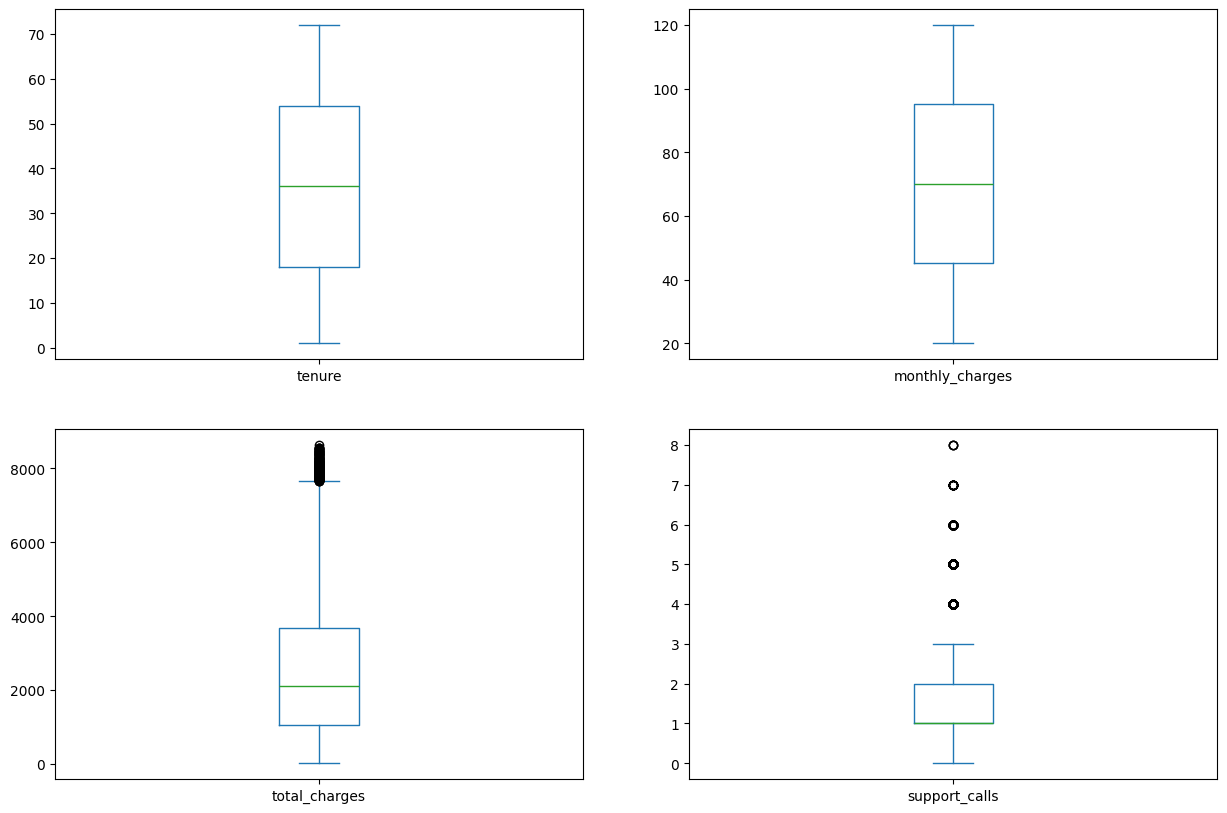

In [13]:
df_dados.select_dtypes(include= [np.number]).plot(kind= 'box', subplots= True, sharex= False, sharey= False, layout= (2,2), figsize= (15,10))

In [14]:
# contanto total de outliers
dados_num = df_dados.select_dtypes(include= [np.number])
Q1 = dados_num.quantile(0.25)
Q3 = dados_num.quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3  + 1.5 * IQR
outliers = ((dados_num < lim_inf) | (dados_num > lim_sup)).sum()
outliers

tenure                0
monthly_charges       0
total_charges       177
support_calls      1325
dtype: int64

In [15]:
# proporção de outliers (%)

(outliers / df_dados.shape[0]) * 100

tenure             0.000
monthly_charges    0.000
total_charges      0.885
support_calls      6.625
dtype: float64

Vamos calcular o valor absoluto de outliers, já que um registro pode ter mais de uma coluna sendo outlier.

In [16]:
n_outliers = ((dados_num < lim_inf) | (dados_num > lim_sup)).any(axis= 1).sum()

print('numero de outliers', n_outliers)

numero de outliers 1486


In [17]:
print('proporção de outliers na base', (n_outliers / df_dados.shape[0]) * 100)

proporção de outliers na base 7.430000000000001


Como existem menos de 10 % de outliers na base. Podemos retirá-las e continuar com as análises.

In [18]:
df_dados = df_dados[~((dados_num < lim_inf) | (dados_num > lim_sup)).any(axis= 1)]
df_dados.shape

(18514, 10)

Correlação entre as variáveis

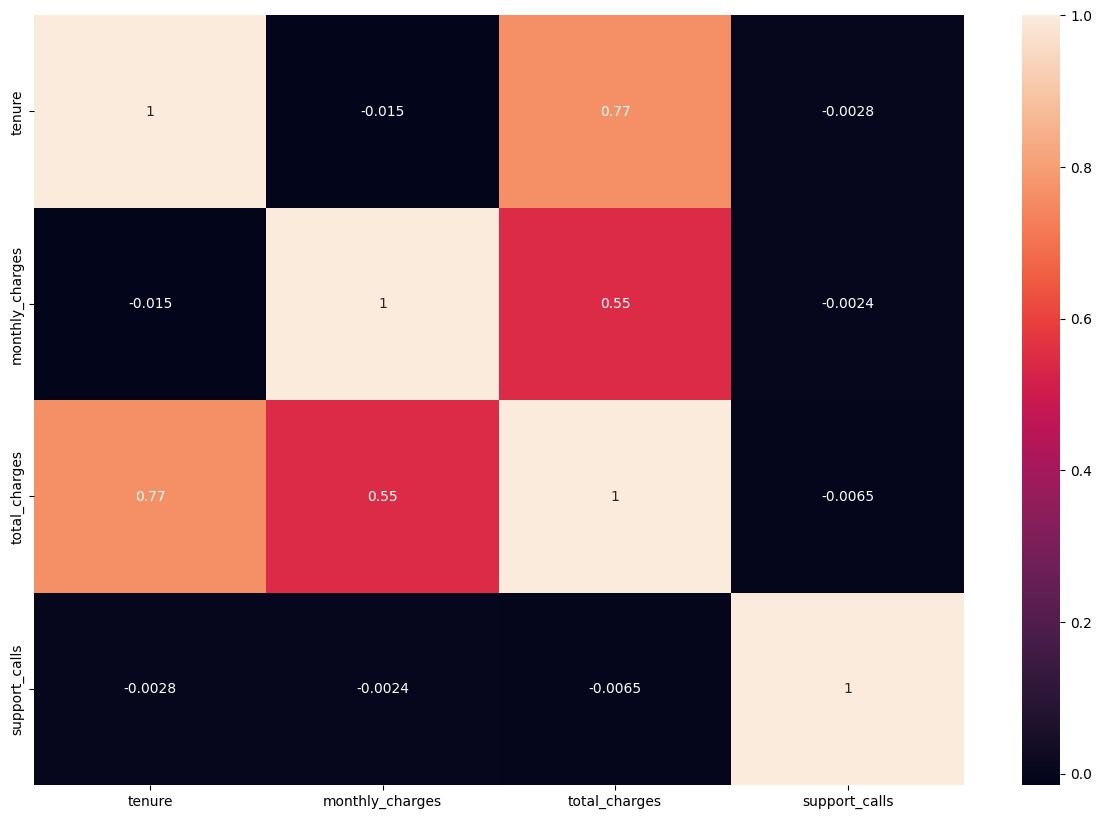

In [19]:
plt.figure(figsize= (15,10))
sns.heatmap(data = dados_num.corr(), annot= True)
plt.show()

Acima, não vemos uma correlação tão próxima de 1 ou -1, mesmo existindo variáveis parcialmente correlacionadas.

visualização de como a variável churn é separada olhando-se para pares das outras variáveis

<Figure size 1500x1000 with 0 Axes>

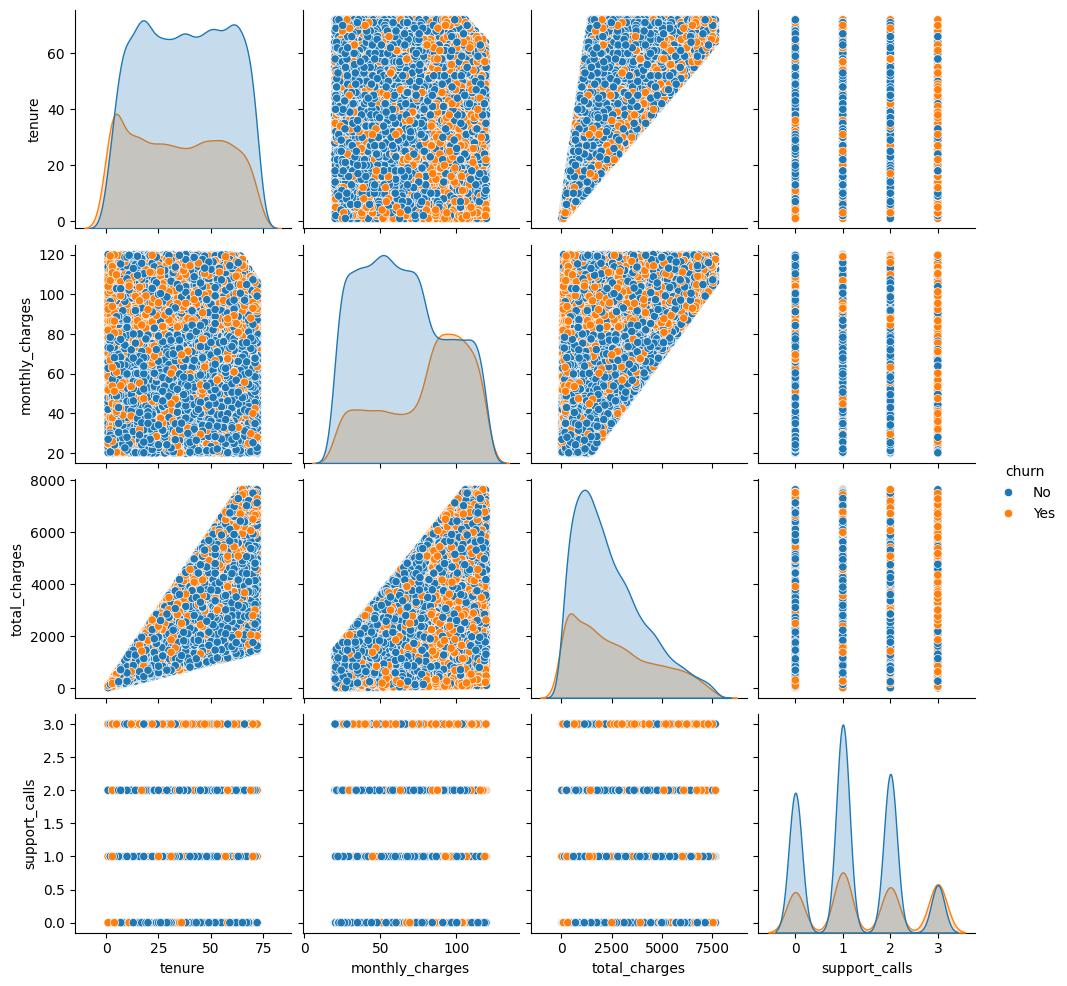

In [20]:
plt.figure(figsize= (15,10))
sns.pairplot(data = df_dados, kind = 'scatter', hue = 'churn')
plt.show()

Olhando o gráfico acima, fica visível a complexidade de separação dos dados quanto ao churn. 
Provavelmente ,quando forem testados os modelos de classificação, irá ocorrer um overfitting dos algoritmos para conseguir encontrar "caminhos" que possam classificar essa variável.

### Entedendo o padrão de comportamento quanto ao Churn

- variáveis numéricas

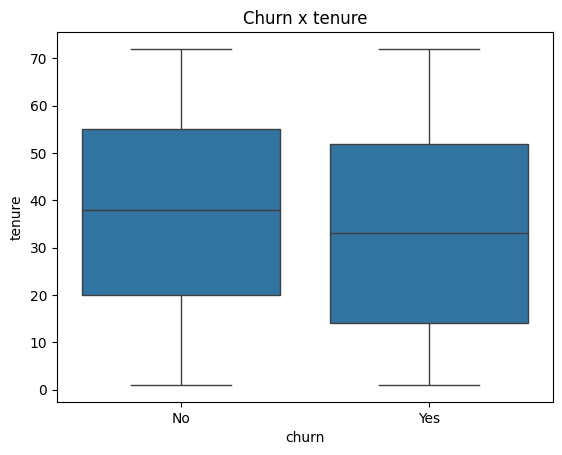

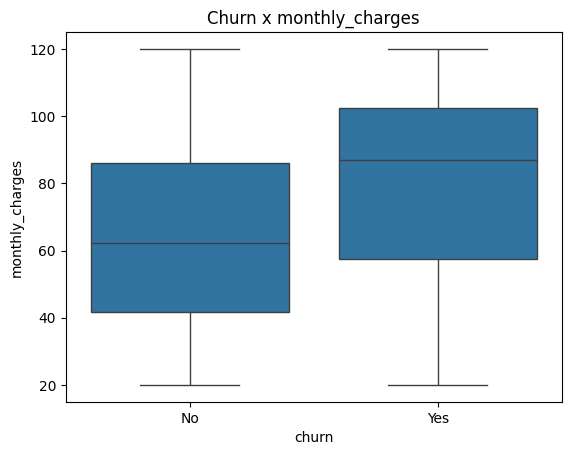

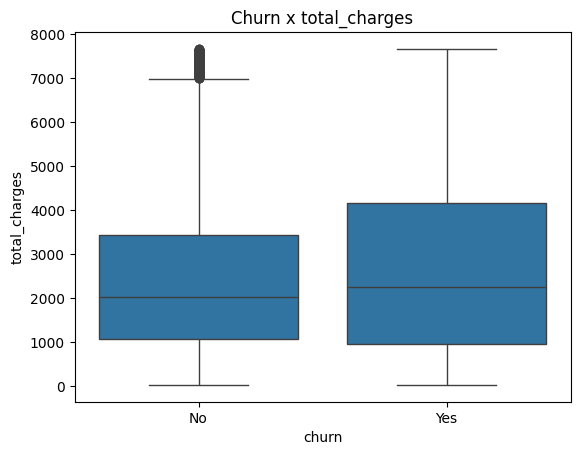

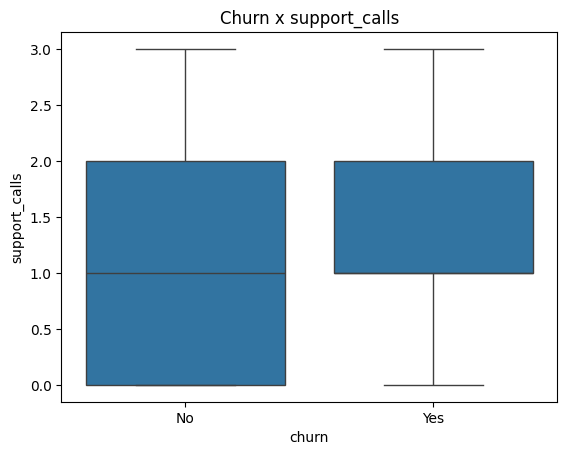

In [21]:
colunas_numericas = df_dados.select_dtypes(include= [np.number])

for col in colunas_numericas:
    plt.title(f'Churn x {col}')
    sns.boxplot(data= df_dados, x= 'churn', y = col)
    plt.show()

A partir da análise acima:

* No grupo dos que deram churn, todos abriram pelo menos um chamado. Enquanto metade dos que continuaram no plano não abriram nenhum.
Além disso, no geral, os que cancelaram o plano tinha um gasto maior em mensalidade.

- variáveis categóricas e booleanas

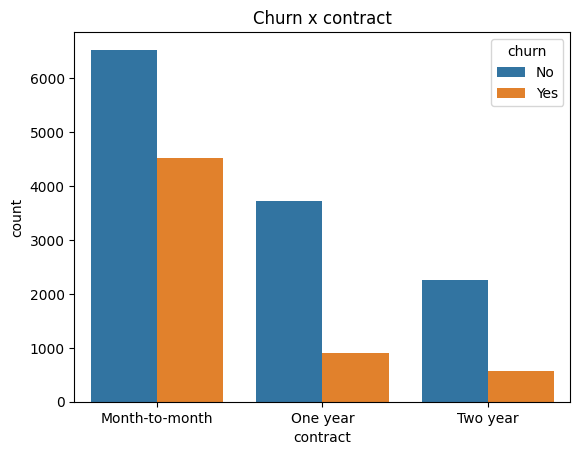

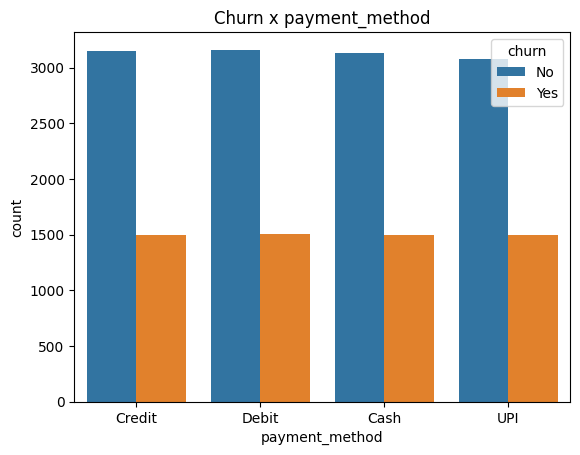

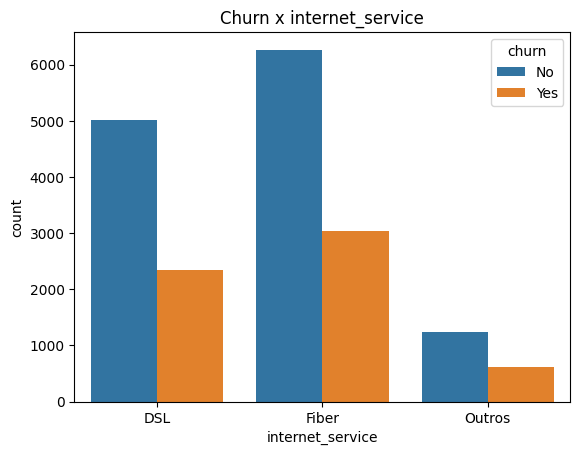

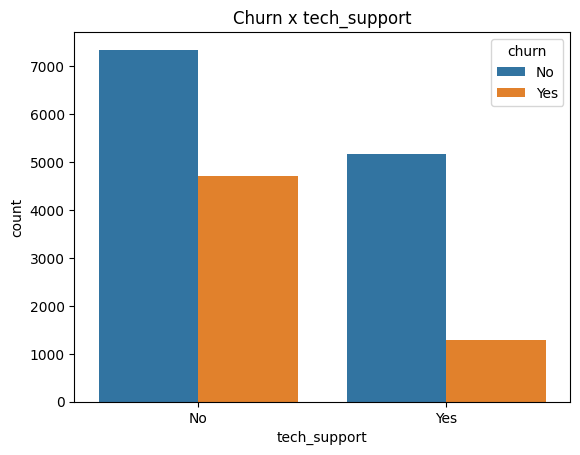

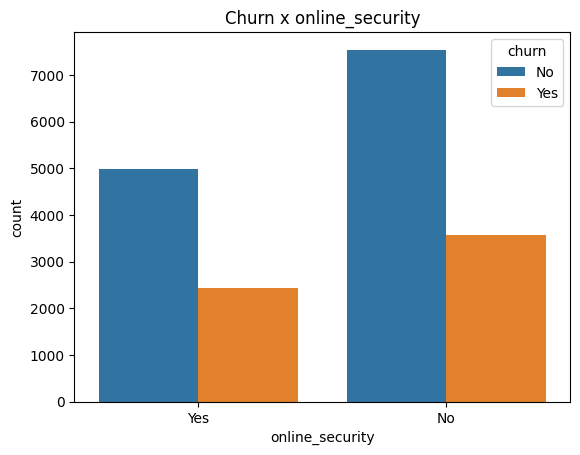

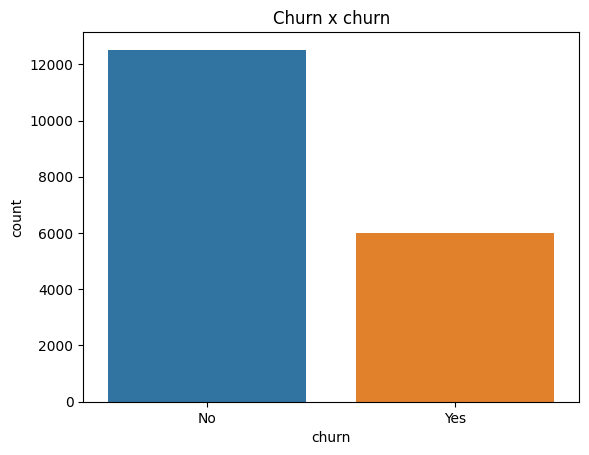

In [22]:
colunas_categoricas = df_dados.select_dtypes(include= ['object'])

for col in colunas_categoricas:
    plt.title(f'Churn x {col}')
    sns.countplot(data= df_dados, x = col, hue = 'churn')
    plt.show()

- A forma de pagamento não tem relação nenhuma com o cancelamento.

- A maioria dos cancelamentos estavam no plano mensal. Porém, isso é esperado já que este tipo de plano é o maior comum.

- A maior parte dos cancelamentos estão em fibra e DSL. Mas, novamente, essas são as opções mais comuns de tipo de internet.

### preparação dos dados para ML

In [23]:
# codificação das variáveis Binárias
var_bin = ['tech_support','online_security','churn']

lb = LabelBinarizer()
for col in var_bin:
    df_dados[col] = lb.fit_transform(df_dados[col])

In [24]:
# aplicando one hot encoding 
df_dados = pd.get_dummies(df_dados)


In [25]:
# prévia dos dados
df_dados.head()

,tenure,monthly_charges,total_charges,tech_support,online_security,support_calls,churn,contract_Month-to-month,contract_One year,contract_Two year,payment_method_Cash,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_DSL,internet_service_Fiber,internet_service_Outros
0,52,54.20,2818.40,0,1,1,0,True,False,False,False,True,False,False,True,False,False
1,15,35.28,529.20,0,0,2,0,True,False,False,False,False,True,False,True,False,False
2,72,78.24,5633.28,0,0,0,0,True,False,False,False,False,True,False,True,False,False
3,61,80.24,4894.64,1,1,0,0,False,True,False,True,False,False,False,False,True,False
5,24,39.66,951.84,0,0,1,0,False,False,True,True,False,False,False,False,True,False


In [26]:
# separando o conjunto de dados
X = df_dados.drop(columns= ['churn'])
y = df_dados['churn']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size= 0.1, random_state= 42)

In [27]:
# padronizando as colunas numéricas (não binárias)

colunas = ['tenure', 'monthly_charges', 'total_charges','support_calls']

scaler = StandardScaler()
X_treino[colunas] = scaler.fit_transform(X_treino[colunas])
X_teste[colunas] = scaler.transform(X_teste[colunas])

### Criação dos modelos e avaliação

antes de mais nada, é importante lembrar que a variável alvo é desbalanceada. Por causa disso, irei testar o desempenho dos modelos em três situações:

* Sem balacemanto de classes



* Com balanceamento de Classes

    1 - Undersampling

    2 - Oversampling

### Sem Balanceamento

In [29]:
gerar_avaliar_modelos(X_treino, y_treino, X_teste, y_teste)

Modelo:  Ridge Classifier 

Acurácia (treino):  0.7746368983315328
Acurácia (teste):  0.7651187904967602 


[[1140   99]
 [ 336  277]] 


              precision    recall  f1-score   support

           0       0.77      0.92      0.84      1239
           1       0.74      0.45      0.56       613

    accuracy                           0.77      1852
   macro avg       0.75      0.69      0.70      1852
weighted avg       0.76      0.77      0.75      1852
 


Modelo:  Decision Tree 

Acurácia (treino):  1.0
Acurácia (teste):  0.7165226781857451 


[[968 271]
 [254 359]] 


              precision    recall  f1-score   support

           0       0.79      0.78      0.79      1239
           1       0.57      0.59      0.58       613

    accuracy                           0.72      1852
   macro avg       0.68      0.68      0.68      1852
weighted avg       0.72      0.72      0.72      1852
 


Modelo:  Naive Bayes 

Acurácia (treino):  0.7366462609530668
Acurácia (teste):  0.735

### Balanceamento das classes (undersampling)

In [30]:
# base de treinamento balanceada

X_under, y_under = undersampling(X_treino, y_treino)

gerar_avaliar_modelos(X_treino= X_under, y_treino= y_under, X_teste= X_teste, y_teste = y_teste)

Modelo:  Ridge Classifier 

Acurácia (treino):  0.7053687534831878
Acurácia (teste):  0.6852051835853131 


[[833 406]
 [177 436]] 


              precision    recall  f1-score   support

           0       0.82      0.67      0.74      1239
           1       0.52      0.71      0.60       613

    accuracy                           0.69      1852
   macro avg       0.67      0.69      0.67      1852
weighted avg       0.72      0.69      0.69      1852
 


Modelo:  Decision Tree 

Acurácia (treino):  1.0
Acurácia (teste):  0.6727861771058316 


[[834 405]
 [201 412]] 


              precision    recall  f1-score   support

           0       0.81      0.67      0.73      1239
           1       0.50      0.67      0.58       613

    accuracy                           0.67      1852
   macro avg       0.66      0.67      0.65      1852
weighted avg       0.71      0.67      0.68      1852
 


Modelo:  Naive Bayes 

Acurácia (treino):  0.6643135797882221
Acurácia (teste):  0.6501079

### Balanceamento das classes (oversampling)

In [31]:
# usando o pacote SMOTE de imbalanced learn

sm = SMOTE(random_state= 0, k_neighbors= 50)

X_res, y_res = sm.fit_resample(X_treino, y_treino)

gerar_avaliar_modelos(X_res, y_res, X_teste, y_teste)

Modelo:  Ridge Classifier 

Acurácia (treino):  0.7798120400744747
Acurácia (teste):  0.7327213822894169 


[[962 277]
 [218 395]] 


              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1239
           1       0.59      0.64      0.61       613

    accuracy                           0.73      1852
   macro avg       0.70      0.71      0.71      1852
weighted avg       0.74      0.73      0.74      1852
 


Modelo:  Decision Tree 

Acurácia (treino):  1.0
Acurácia (teste):  0.7278617710583153 


[[959 280]
 [224 389]] 


              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1239
           1       0.58      0.63      0.61       613

    accuracy                           0.73      1852
   macro avg       0.70      0.70      0.70      1852
weighted avg       0.73      0.73      0.73      1852
 


Modelo:  Naive Bayes 

Acurácia (treino):  0.6994414398439578
Acurácia (teste):  0.6706263

### Análise dos principais fatores relacionados ao churn

<Axes: title={'center': 'Ranking de importâncias das variáveis'}>

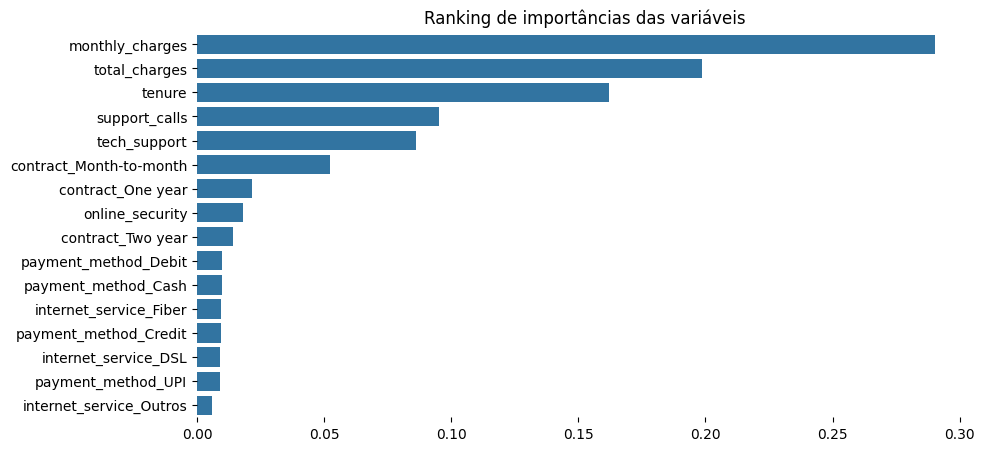

In [ ]:
modelo = RandomForestClassifier()

X = df_dados.drop(columns= ['churn'])
y = df_dados['churn']
modelo.fit(X, y)

colunas = X.columns
importancias = modelo.feature_importances_

dados = list(zip(colunas, importancias))

#ordenando pelo segundo elemento da tupla
dados = sorted(dados, key = (lambda x : x[1]), reverse= True)

plt.figure(figsize= (10, 5))
plt.box(False)
plt.title('Ranking de importâncias das variáveis')
sns.barplot(y = [ tupla[0] for tupla in dados], x = [ tupla[1] for tupla in dados])


# Conclusões

**1 - Análise descritiva e Ranking de importâncias**

Segundo o treinamento do randomforest em toda a base, o atributo que mais contribui para o encerramento do contrato foi o valor da mensalidade. Durante a etapa de análise descritiva vimos que o grupo dos que encerraram o contrato tinha , em sua maioria, um valor de mensalidade acima dos que não deram churn.

Além disso, o atributo support_calls , que está em 4º no ranking, foi notadamente diferente durante a análise descritiva.
Lá, vimos que todos os que encerraram o contrato tinham aberto pelo menos um chamado.
Portanto,as análises estariam indicando que os clientes não estão satisfeitos com o valor do plano e os serviços disponíveis.



**2 - Escolha do melhor modelo: RandomForest**

A melhor estratégia foi *desconsiderar o desbalanceamento das classes*, pois os balanceamentos pioraram as métricas de avaliação. 

Justificativas:
*  aplicar undersampling acabou jogando muito informação relevante fora, prejudicando o modelo.

* o oversampling pode ter gerado amostras sintéticas que não representam os dados reais, piorando assim as métricas avaliadas.

Considerando então as classes desbalanceadas, os modelos que tiveram as melhores acurácias e métricas de avaliação foram o randomforest e o xgboostclassifier.
O randomforest se destacou porque entre as perdas e compensações, ele teve melhor f1-score do que o xgboost.

